# 02 — Feature Engineering Validation
Verifies the outputs of `src/features/build_all.py`:
- Distribution of every engineered feature
- Correlation matrix of the tabular feature set
- 1-week sample: original vs engineered signals
- NaN audit: zero NaN in train, expected NaN in test
- Final shapes for Phase 3 model input

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
plt.rcParams.update({'figure.figsize': (14, 4), 'axes.titlesize': 12, 'axes.titleweight': 'bold'})
sns.set_theme(style='darkgrid', palette='muted')

PROC = Path('..') / 'data' / 'processed'

train = pd.read_parquet(PROC / 'features_tabular_train.parquet')
test  = pd.read_parquet(PROC / 'features_tabular_test.parquet')
meta  = json.loads((PROC / 'split_metadata.json').read_text())

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
print('Split at   :', meta['split_timestamp'])

Train shape: (1641572, 24)
Test  shape: (415052, 24)
Split at   : 2010-02-11T15:31:00


## 1. Final Shapes

In [2]:
seq_train = np.load(PROC / 'sequences_train.npy')
seq_test  = np.load(PROC / 'sequences_test.npy')

print(f'Tabular train  : {train.shape[0]:>10,} rows  x  {train.shape[1]} features')
print(f'Tabular test   : {test.shape[0]:>10,} rows  x  {test.shape[1]} features')
print(f'Sequences train: {seq_train.shape}  (N x window x features)  dtype={seq_train.dtype}')
print(f'Sequences test : {seq_test.shape}  dtype={seq_test.dtype}')
print(f'Train date range: {train.index.min()} -> {train.index.max()}')
print(f'Test  date range: {test.index.min()}  -> {test.index.max()}')

Tabular train  :  1,641,572 rows  x  24 features
Tabular test   :    415,052 rows  x  24 features
Sequences train: (329616, 60, 7)  (N x window x features)  dtype=float32
Sequences test : (80069, 60, 7)  dtype=float32
Train date range: 2006-12-17 17:24:00 -> 2010-02-11 15:30:00
Test  date range: 2010-02-11 15:31:00  -> 2010-11-26 21:02:00


## 2. NaN Audit
Train must be **zero NaN**. Test preserves NaN rows from sensor gaps > 5 min.

In [3]:
train_nan = train.isna().sum().sum()
test_nan_rows = test.isna().any(axis=1).sum()
test_nan_cells = test.isna().sum().sum()

print(f'Train NaN cells    : {train_nan}   <- must be 0')
print(f'Test  NaN rows     : {test_nan_rows:,}   ({test_nan_rows/len(test)*100:.2f}% of test)')
print(f'Test  NaN cells    : {test_nan_cells:,}')

assert train_nan == 0, 'FAIL: training features contain NaN!'
print()
print('PASS: training features are fully numeric.')

# Show which test columns have NaN
test_col_nan = test.isna().sum()
print('\nTest NaN counts per column (top 10):')
print(test_col_nan[test_col_nan > 0].sort_values(ascending=False).head(10))

Train NaN cells    : 0   <- must be 0
Test  NaN rows     : 18,795   (4.53% of test)
Test  NaN cells    : 260,127

PASS: training features are fully numeric.

Test NaN counts per column (top 10):
gap_diff_1               14478
Global_active_power      14475
Global_reactive_power    14475
Voltage                  14475
Sub_metering_1           14475
Global_intensity         14475
Sub_metering_3           14475
gap_lag_1                14475
gap_lag_60               14475
Sub_metering_2           14475
dtype: int64


## 3. Temporal Leakage Check

In [4]:
split_ts = pd.Timestamp(meta['split_timestamp'])
overlap = (train.index >= split_ts).sum()

print(f'Split timestamp : {split_ts}')
print(f'Train max index : {train.index.max()}')
print(f'Test  min index : {test.index.min()}')
print(f'Overlap count   : {overlap}   <- must be 0')

assert overlap == 0, 'FAIL: temporal leakage detected!'
assert train.index.max() < test.index.min(), 'FAIL: train/test overlap!'
print('PASS: no temporal leakage.')

Split timestamp : 2010-02-11 15:31:00
Train max index : 2010-02-11 15:30:00
Test  min index : 2010-02-11 15:31:00
Overlap count   : 0   <- must be 0
PASS: no temporal leakage.


## 4. Distributions of Engineered Features

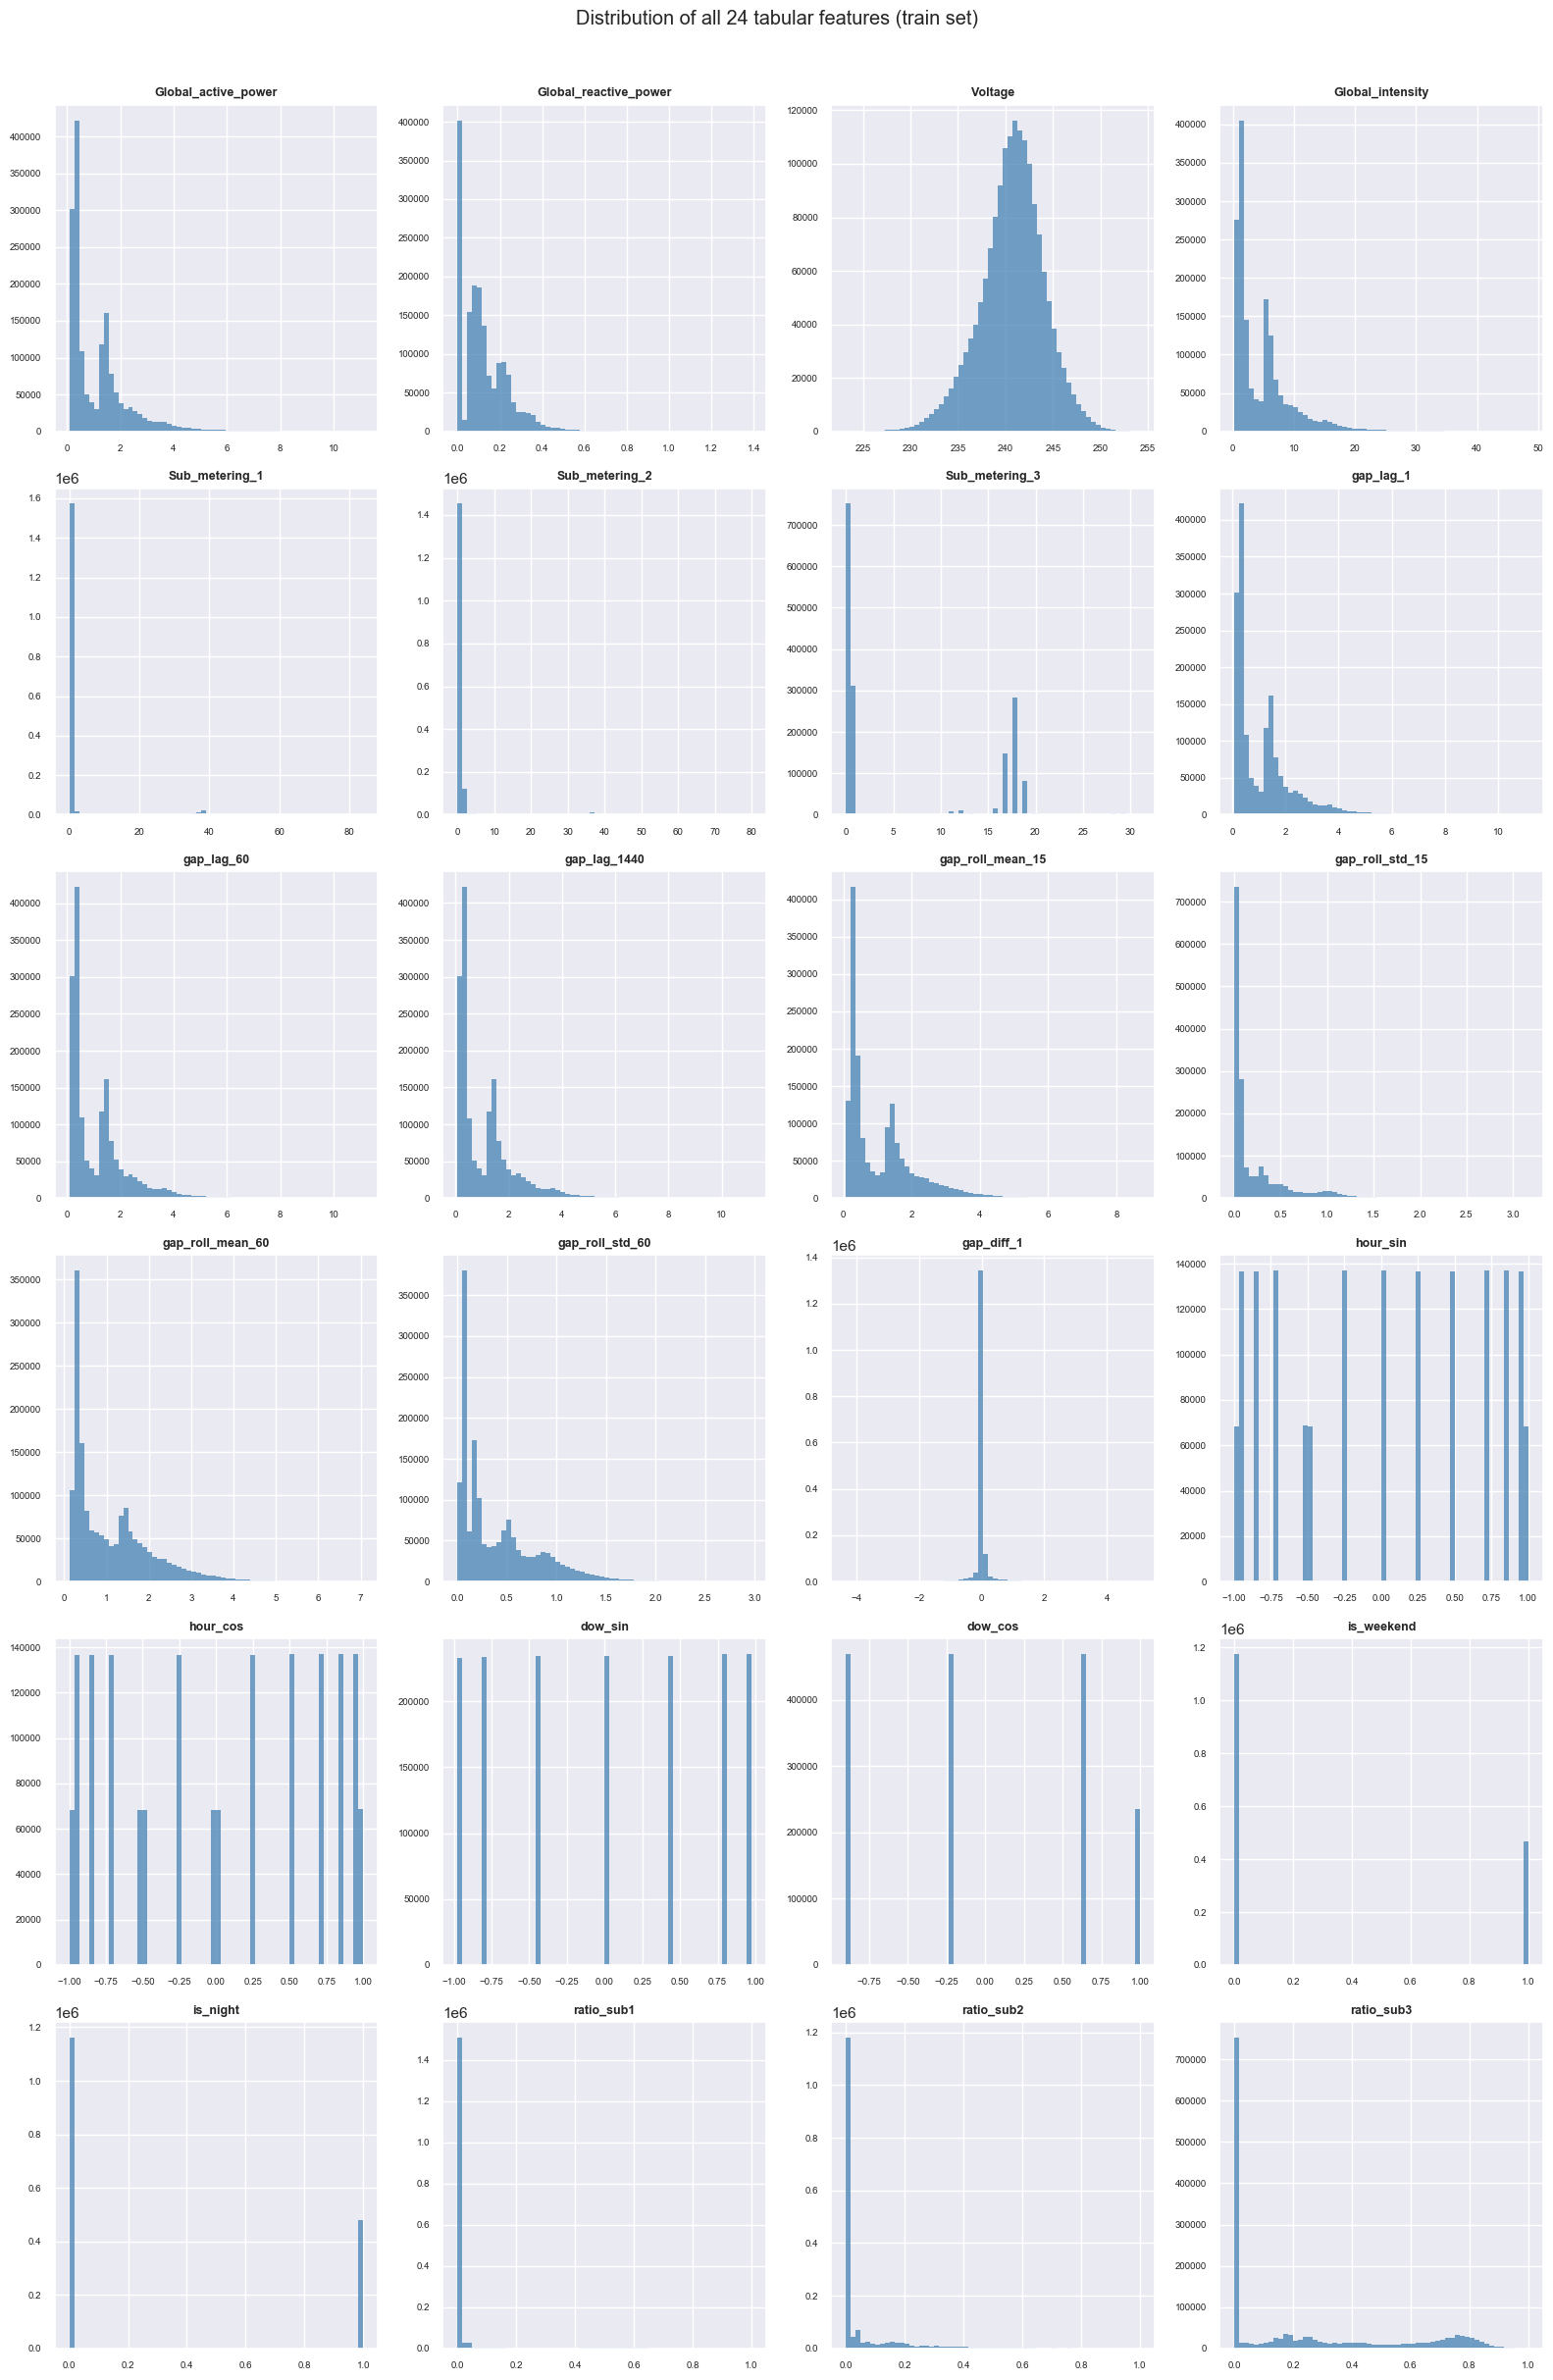

In [5]:
cols = train.columns.tolist()
n_cols = len(cols)
n_rows_plot = (n_cols + 3) // 4  # 4 per row

fig, axes = plt.subplots(n_rows_plot, 4, figsize=(16, 4 * n_rows_plot))
axes_flat = axes.flatten()

for i, col in enumerate(cols):
    axes_flat[i].hist(train[col].dropna(), bins=60, edgecolor='none', alpha=0.75, color='steelblue')
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].set_xlabel('')
    axes_flat[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Distribution of all 24 tabular features (train set)', y=1.01)
fig.tight_layout()
plt.show()

## 5. Correlation Matrix

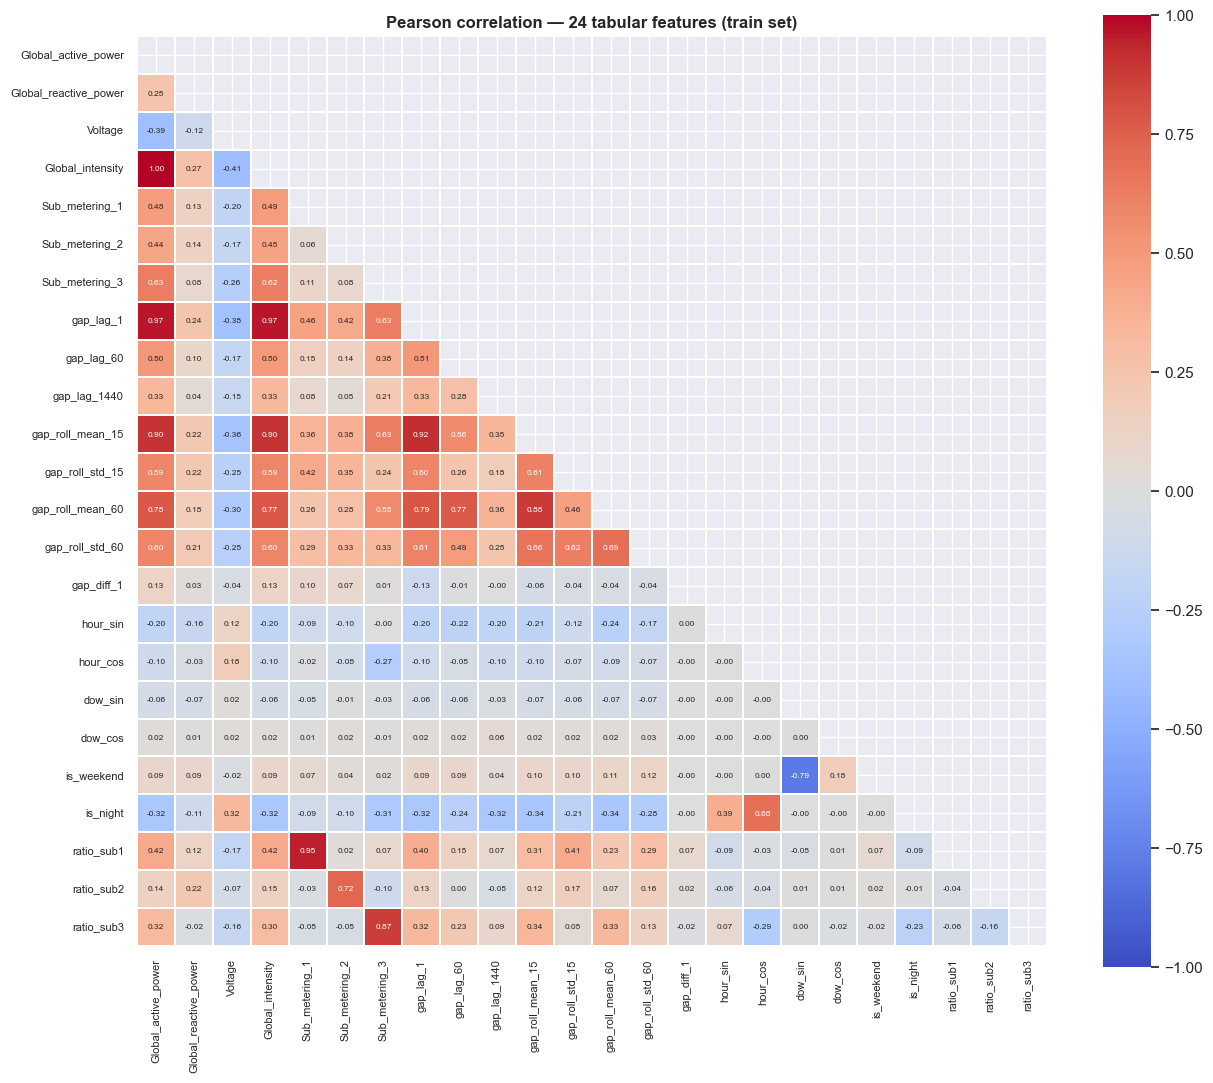

Pairs with |r| > 0.85 (9 pairs):
               A                   B        r
Global_intensity Global_active_power 0.998958
       gap_lag_1 Global_active_power 0.967990
       gap_lag_1    Global_intensity 0.966721
      ratio_sub1      Sub_metering_1 0.946974
gap_roll_mean_15           gap_lag_1 0.918199
gap_roll_mean_15 Global_active_power 0.902044
gap_roll_mean_15    Global_intensity 0.899195
gap_roll_mean_60    gap_roll_mean_15 0.880538
      ratio_sub3      Sub_metering_3 0.873036


In [6]:
corr = train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.3, annot_kws={'size': 6},
    square=True, ax=ax,
)
ax.set_title('Pearson correlation — 24 tabular features (train set)')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# Highly correlated pairs
corr_vals = corr.where(~mask).stack().reset_index()
corr_vals.columns = ['A', 'B', 'r']
high = corr_vals[corr_vals['r'].abs() > 0.85].sort_values('r', ascending=False)
print(f'Pairs with |r| > 0.85 ({len(high)} pairs):')
print(high.to_string(index=False))

## 6. One-Week Sample: Original vs Engineered Features

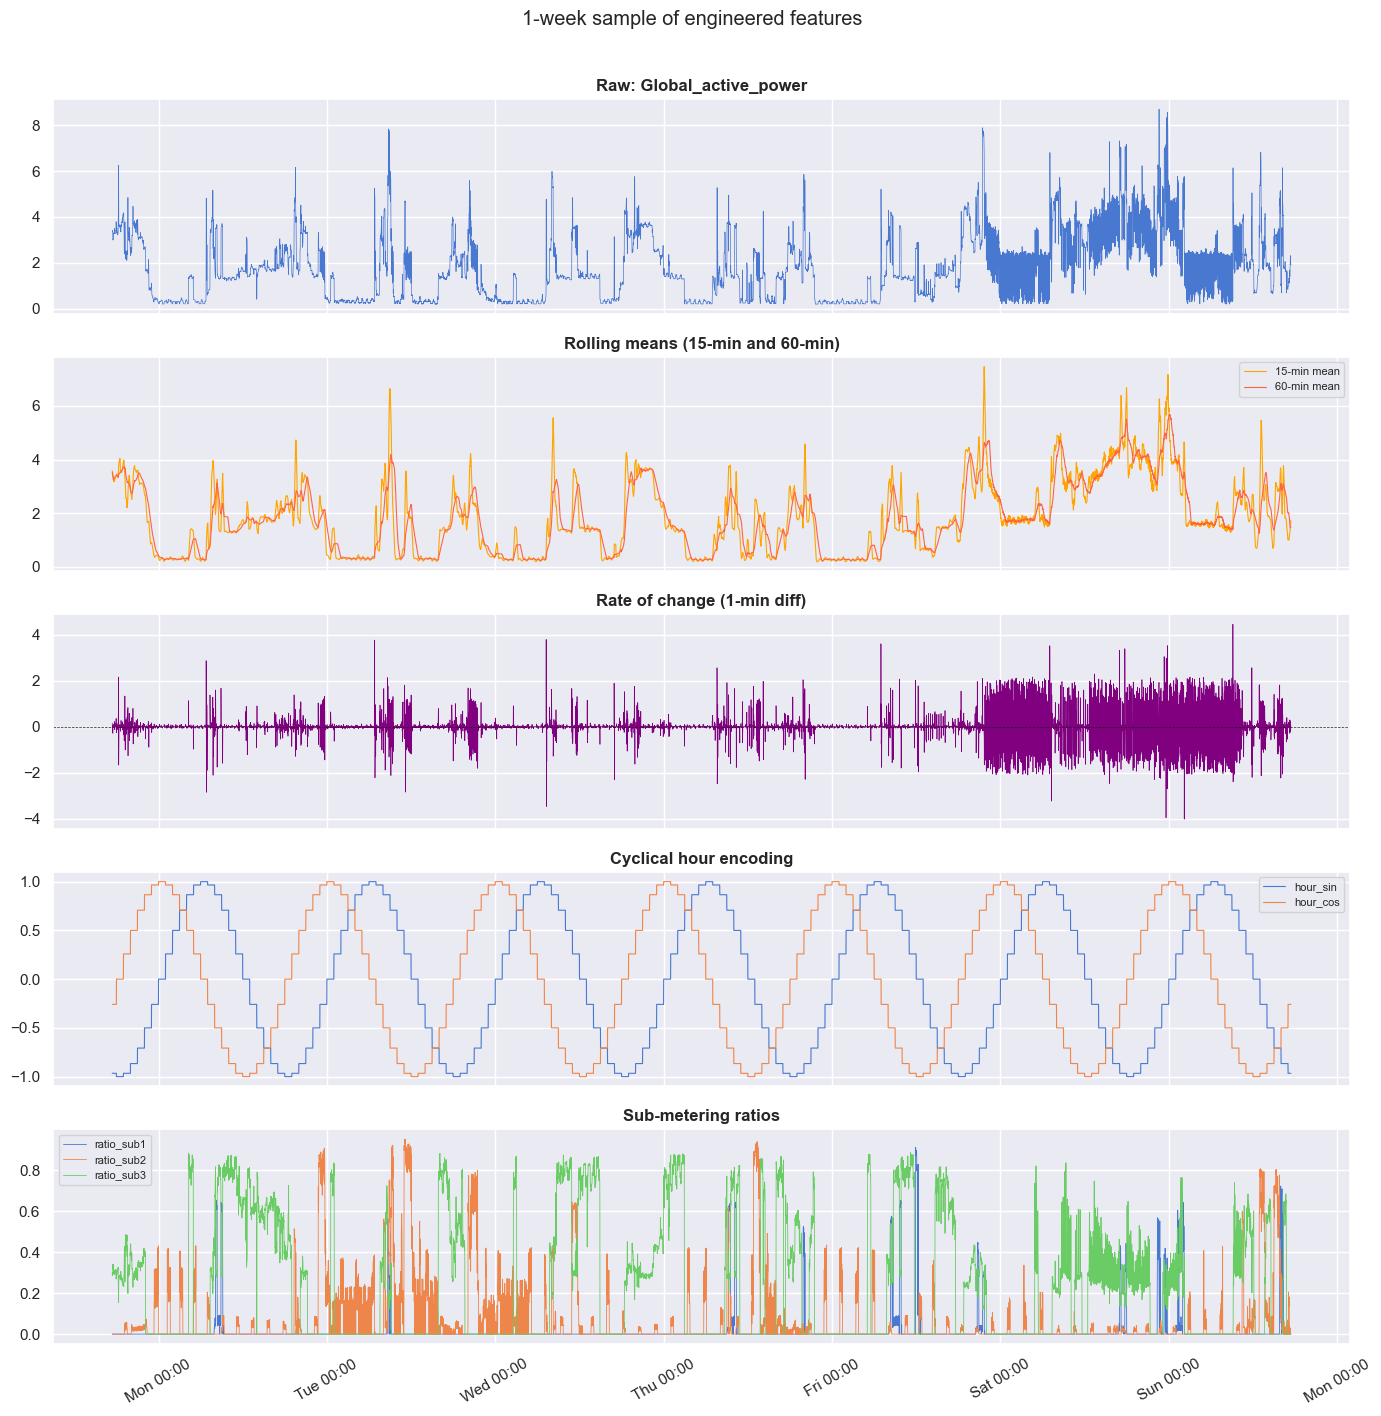

In [7]:
# Pick first full week of training data
week_start = train.index[0]
week_end   = week_start + pd.Timedelta('7D')
sample = train.loc[week_start:week_end]

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

axes[0].plot(sample.index, sample['Global_active_power'], lw=0.5, label='raw GAP')
axes[0].set_title('Raw: Global_active_power')

axes[1].plot(sample.index, sample['gap_roll_mean_15'], lw=0.8, label='15-min mean', color='orange')
axes[1].plot(sample.index, sample['gap_roll_mean_60'], lw=0.8, label='60-min mean', color='tomato')
axes[1].legend(fontsize=8)
axes[1].set_title('Rolling means (15-min and 60-min)')

axes[2].plot(sample.index, sample['gap_diff_1'], lw=0.5, color='purple')
axes[2].axhline(0, color='k', lw=0.5, ls='--')
axes[2].set_title('Rate of change (1-min diff)')

axes[3].plot(sample.index, sample['hour_sin'], lw=0.8, label='hour_sin')
axes[3].plot(sample.index, sample['hour_cos'], lw=0.8, label='hour_cos')
axes[3].legend(fontsize=8)
axes[3].set_title('Cyclical hour encoding')

axes[4].plot(sample.index, sample['ratio_sub1'], lw=0.6, label='ratio_sub1')
axes[4].plot(sample.index, sample['ratio_sub2'], lw=0.6, label='ratio_sub2')
axes[4].plot(sample.index, sample['ratio_sub3'], lw=0.6, label='ratio_sub3')
axes[4].legend(fontsize=8)
axes[4].set_title('Sub-metering ratios')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %H:%M'))
    ax.xaxis.set_major_locator(mdates.DayLocator())

axes[-1].tick_params(axis='x', rotation=30)
fig.suptitle('1-week sample of engineered features', y=1.01)
fig.tight_layout()
plt.show()

## 7. Sequence Tensor Spot-Check

Train sequences shape : (329616, 60, 7)
Test  sequences shape : (80069, 60, 7)
dtype                 : float32
Any NaN in train seqs : False
Any NaN in test  seqs : False
Mean (should be ~0)   : -1e-04
Std  (should be ~1)   : 0.9999


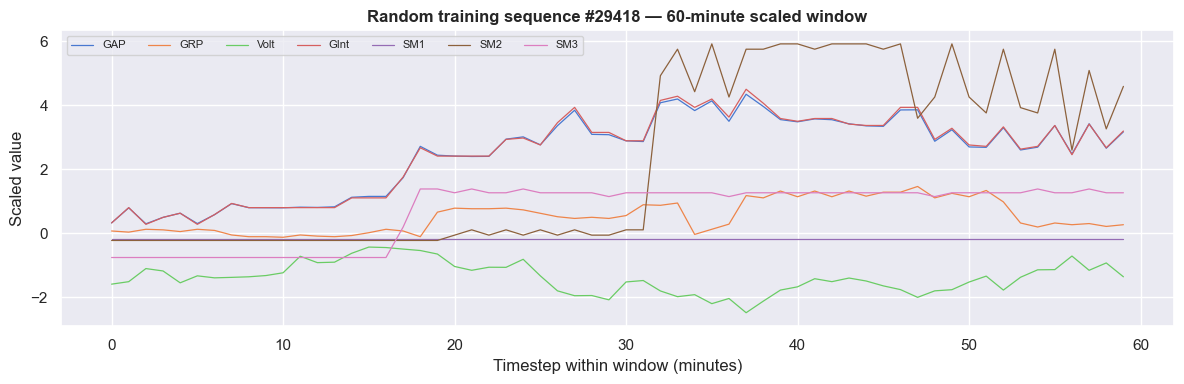

In [8]:
print('Train sequences shape :', seq_train.shape)
print('Test  sequences shape :', seq_test.shape)
print('dtype                 :', seq_train.dtype)
print('Any NaN in train seqs :', np.isnan(seq_train).any())
print('Any NaN in test  seqs :', np.isnan(seq_test).any())
print('Mean (should be ~0)   :', np.nanmean(seq_train).round(4))
print('Std  (should be ~1)   :', np.nanstd(seq_train).round(4))

# Plot one random sequence (all 7 channels)
rng = np.random.default_rng(42)
idx = rng.integers(0, len(seq_train))
sample_seq = seq_train[idx]  # (60, 7)
channel_names = ['GAP', 'GRP', 'Volt', 'GInt', 'SM1', 'SM2', 'SM3']

fig, ax = plt.subplots(figsize=(12, 4))
for ch, name in enumerate(channel_names):
    ax.plot(sample_seq[:, ch], label=name, lw=0.9)
ax.legend(fontsize=8, ncol=7)
ax.set_xlabel('Timestep within window (minutes)')
ax.set_ylabel('Scaled value')
ax.set_title(f'Random training sequence #{idx} — 60-minute scaled window')
plt.tight_layout()
plt.show()

## Summary

| Artefact | Shape | NaN |
|---|---|---|
| `features_tabular_train.parquet` | (train_rows, 24) | 0 |
| `features_tabular_test.parquet` | (test_rows, 24) | preserved |
| `features_tabular_train_scaled.parquet` | (train_rows, 24) | 0 |
| `features_tabular_test_scaled.parquet` | (test_rows, 24) | preserved |
| `sequences_train.npy` | (N, 60, 7) float32 | 0 |
| `sequences_test.npy` | (M, 60, 7) float32 | 0 |
| `scaler_tabular.pkl` | StandardScaler (24 features) | — |
| `scaler_lstm.pkl` | StandardScaler (7 features) | — |
| `split_metadata.json` | split timestamp + row counts | — |

**Next step:** Phase 3 — Model training (Isolation Forest + LSTM Autoencoder).